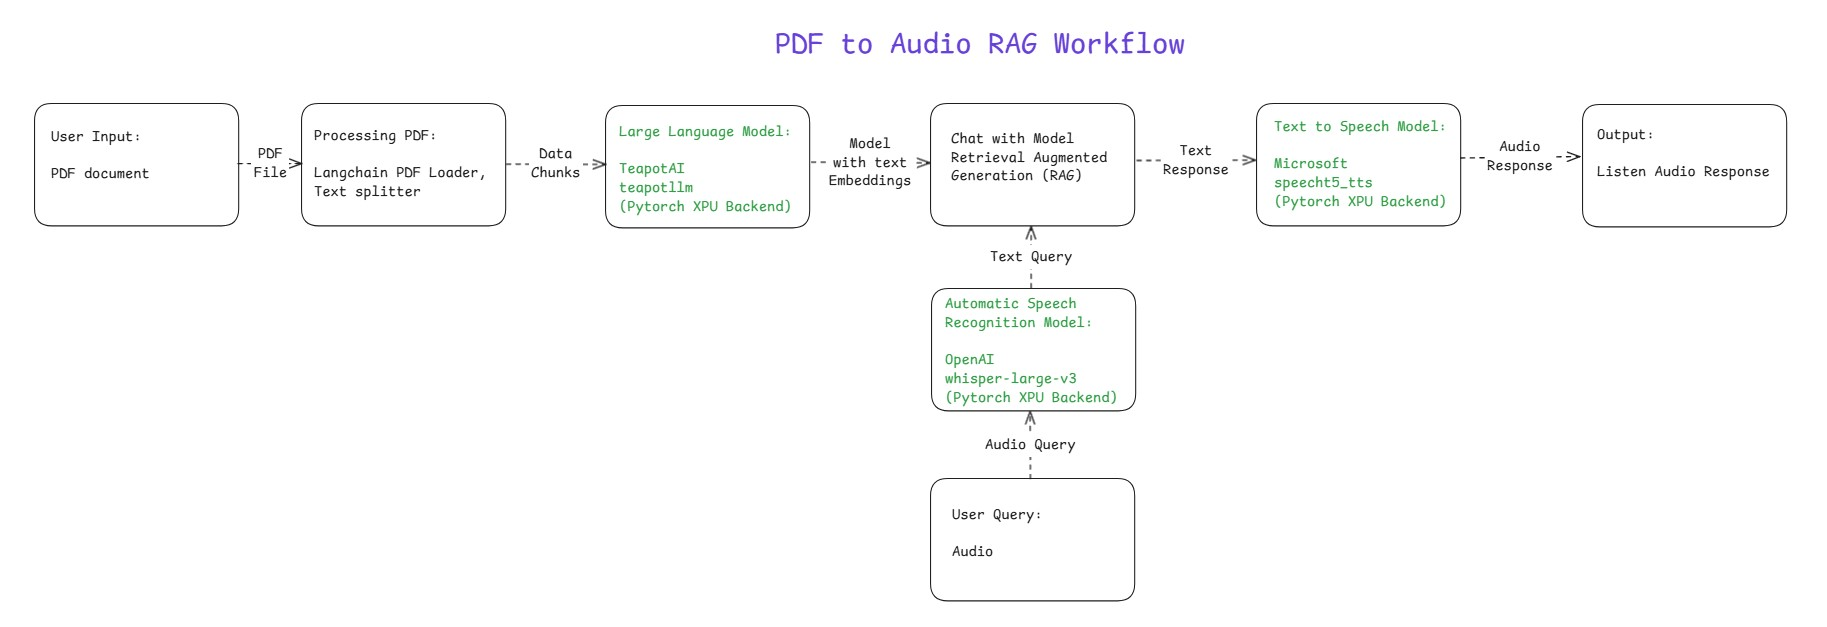

In [23]:
import os
import torch
import logging
import warnings
import torchaudio
import soundfile as sf
from teapotai import TeapotAI
from datasets import load_dataset
from IPython.display import Audio as display_Audio, display
from langchain_community.document_loaders import PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from transformers import AutoModelForSpeechSeq2Seq, AutoProcessor, pipeline

logging.basicConfig(level=logging.INFO)
warnings.filterwarnings("ignore")

In [2]:
def process_pdf(pdf_path):
    """
    """
    try:
        if os.path.basename(pdf_path).endswith(".pdf"):
            logging.info(f" Selected {pdf_path} PDF file.")
            loader = PyPDFLoader(pdf_path)
            pages = loader.load()
            text_splitter = RecursiveCharacterTextSplitter(
                chunk_size=800,
                chunk_overlap=200,
                length_function=len,
            )
            chunks = text_splitter.split_documents(pages)
            documents = []
            for i, chunk in enumerate(chunks):
                page_info = chunk.metadata.get('page', 'Unknown')
                chunk_text = chunk.page_content
                documents.append(f"Chunk {i+1} (Page {page_info}): {chunk_text}")
            return documents
        else:
            logging.info("Unable to find the PDF file.")
    except Exception as e:
        logging.exception(f" Error while processing the PDF file: {str(e)}")

In [3]:
pdf_path = "dpcpp_cpp_compiler_developer_guide_and_reference.pdf"

documents = process_pdf(pdf_path)

INFO:root: Selected dpcpp-cpp-compiler_developer-guide-reference_2025.1-767253-848584.pdf PDF file.



In [4]:
def generate_embeddings(documents):
    """
    """
    try:
        if documents:
            logging.info("Found document.")
            teapot_ai = TeapotAI(documents=documents)
            return teapot_ai
        else:
            logging.info("No document found.")
    except Exception as e:
        logging.exception(f" Error while generating embeddings using TeapotAI : {str(e)}")    

In [5]:
teapot_ai = generate_embeddings(documents)

INFO:root:Found document.


 _____                      _         _    ___        __o__    _;;
|_   _|__  __ _ _ __   ___ | |_      / \  |_ _|   __ /-___-\__/ /
  | |/ _ \/ _` | '_ \ / _ \| __|    / _ \  | |   (  |       |__/
  | |  __/ (_| | |_) | (_) | |_    / ___ \ | |    \_|~~~~~~~|
  |_|\___|\__,_| .__/ \___/ \__/  /_/   \_\___|      \_____/
               |_|   
Loading Model
Generating embeddings for documents...


Document Embedding: 100%|████████████████████████████████████████████████████████| 3123/3123 [01:08<00:00, 45.68 doc/s]


In [6]:
def initialize_audio_models():
    model_id = "openai/whisper-large-v3"
    device = "xpu" if torch.xpu.is_available() else "cpu"
    torch_dtype = torch.float16 if torch.xpu.is_available() else torch.float32
    model = AutoModelForSpeechSeq2Seq.from_pretrained(pretrained_model_name_or_path = model_id, 
                                                      torch_dtype=torch_dtype, 
                                                      low_cpu_mem_usage=True, 
                                                      use_safetensors=True,
                                                     )
    model.to(device)
    
    # Enable static cache and compile the forward pass
    # model.generation_config.cache_implementation = "static"
    # model.generation_config.max_new_tokens = 256
    # model.forward = torch.compile(model.forward, mode="reduce-overhead", fullgraph=True)
    # model = torch.compile(model, mode="reduce-overhead", fullgraph=True)
    model = torch.compile(model)
    
    processor = AutoProcessor.from_pretrained(pretrained_model_name_or_path=model_id)
    
    pipe = pipeline(
        "automatic-speech-recognition",
        model=model,
        tokenizer=processor.tokenizer,
        feature_extractor=processor.feature_extractor,
        torch_dtype=torch_dtype,
        device=device,
        return_timestamps=True,
        # batch_size=16,
    )
    synthesiser = pipeline("text-to-speech", 
                           "microsoft/speecht5_tts", 
                           device=device, 
                           torch_dtype=torch_dtype
                          )
    # synthesiser = pipeline("text-to-speech", "microsoft/speecht5_tts")
    embeddings_dataset = load_dataset("Matthijs/cmu-arctic-xvectors", split="validation")
    speaker_embedding = torch.tensor(embeddings_dataset[7306]["xvector"]).unsqueeze(0).to(device, torch_dtype)
    # speaker_embedding.to(device)    
    # path_audio = "./Recording.wav"
    # input_sample_rate=48000
    # output_sample_rate=16000
    return pipe, synthesiser, speaker_embedding

In [7]:
pipe, synthesiser, speaker_embedding = initialize_audio_models()

Using the latest cached version of the dataset since Matthijs/cmu-arctic-xvectors couldn't be found on the Hugging Face Hub
Found the latest cached dataset configuration 'default' at C:\Users\gta\.cache\huggingface\datasets\Matthijs___cmu-arctic-xvectors\default\0.0.1\5c1297a9eb6c91714ea77c0d4ac5aca9b6a952e5 (last modified on Mon Jun 23 10:56:47 2025).


In [8]:
def process_input_query(path_audio):
    waveform, sample_rate = torchaudio.load(path_audio)
    # waveform_resampled = torchaudio.functional.resample(waveform, orig_freq=input_sample_rate, new_freq=output_sample_rate) #change sample rate to 16000 to match training. 
    # sample = waveform_resampled.numpy()[0]
    sample = waveform.numpy()[0]
    with torch.no_grad():
        result = pipe(sample)
    logging.info(f"Query: {result['text']}")
    question = result["text"]
    return question
    
    #Changing sample rate might change the transcription

In [20]:
# path_audio = "./1st_audio_query.wav"
path_audio = "./input_audio_query.wav"
query = process_input_query(path_audio)

INFO:root:Query:  how SIMD enabled function pointers work


In [21]:
def get_response(question, teapot_ai):
    logging.info(f"Query: {query}\n")
    answer = teapot_ai.chat([
        {
            "role":"system",
            "content": "You are an agent designed to answer the questions."
        },
        {
            "role":"user",
            "content": question
        }
    ])
    logging.info(f"Response: {answer}\n")
    with torch.no_grad():
        speech = synthesiser(answer, forward_params={"speaker_embeddings": speaker_embedding})
    audio_name="output_audio_response.wav"
    sf.write(audio_name, speech["audio"], samplerate=speech["sampling_rate"])
    logging.info(f"Generated audio file name: {audio_name}\n")
    display(display_Audio(audio_name))
    return answer

In [22]:
answer = get_response(query, teapot_ai)
# question

INFO:root:Query:  how SIMD enabled function pointers work

INFO:root:Response: SIMD-enabled function pointers work by generating short vector variants of the function that you requested, which can perform your function's operation on multiple arguments in a single invocation.

INFO:root:Generated audio file name: output_audio_response.wav

